# Exploración y preprocesamiento del texto

In [2]:
%pip install gensim datasets spacy nltk pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 716.4 kB/s  0:01:20m0:00:0100:02

[notice] A new release of pip is available: 26.2 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import time
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import gensim.downloader as api

import utils as U

SEED = 42
rng = np.random.default_rng(SEED)

# Subconjunto de trabajo (prefijo del corpus, mismo para todos los modelos).
# El enunciado permite >= 20M tokens. None = corpus completo.
MAX_TOKENS = 30_000_000
MIN_COUNT = 5          # umbral elegido para el pipeline (la tabla de abajo compara varios)
WINDOW = 5
CACHE = Path("cache"); CACHE.mkdir(exist_ok=True)

corpus = load_dataset("Salesforce/wikitext", "wikitext-103-raw-v1")
glove = api.load("glove-wiki-gigaword-100")

README.md: 0.00B [00:00, ?B/s]

wikitext-103-raw-v1/test-00000-of-00001.(…):   0%|          | 0.00/733k [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00000-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/train-00001-of-00002(…):   0%|          | 0.00/157M [00:00<?, ?B/s]

wikitext-103-raw-v1/validation-00000-of-(…):   0%|          | 0.00/657k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/4358 [00:00<?, ? examples/s]

Generating train split:   0%|          | 0/1801350 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3760 [00:00<?, ? examples/s]

[==================================================] 100.0% 128.1/128.1MB downloaded


## 2.1 ¿Cuántos artículos, líneas y tokens tiene el corpus?

In [5]:
stats = {split: U.corpus_stats(corpus[split]["text"]) for split in corpus}
df_stats = pd.DataFrame(stats).T
df_stats.loc["total"] = df_stats.sum()
df_stats

,filas,filas_no_vacias,articulos,tokens_crudos
test,4358,2891,62,241211
train,1801350,1165029,29436,101425671
validation,3760,2461,60,213886
total,1809468,1170381,29558,101880768


## 2.2 Normalización y consistencia con GloVe

In [6]:
gv = glove.key_to_index
print("Palabras en GloVe:", len(gv))
print("Con mayúsculas   :", sum(w != w.lower() for w in gv))
print("Solo puntuación  :", sum(not any(c.isalnum() for c in w) for w in gv))
print("Con dígitos      :", sum(any(c.isdigit() for c in w) for w in gv))
print("Con guion        :", sum("-" in w for w in gv))
sondeo = ["n't", "'s", "'re", "well-known", "state-of-the-art", "1,000", "3.5",
          "e-mail", "<unk>", ".", ",", "the", "u.s.", "mr.", "2010"]
print({w: (w in gv) for w in sondeo})

Palabras en GloVe: 400000
Con mayúsculas   : 0
Solo puntuación  : 177
Con dígitos      : 48970
Con guion        : 33402
{"n't": True, "'s": True, "'re": True, 'well-known': True, 'state-of-the-art': True, '1,000': True, '3.5': True, 'e-mail': True, '<unk>': False, '.': True, ',': True, 'the': True, 'u.s.': True, 'mr.': True, '2010': True}


## 2.3 Tokenizador por palabra vs. librería

In [7]:
import spacy
from nltk.tokenize import NLTKWordTokenizer

nlp = spacy.blank("en")
nltk_tok = NLTKWordTokenizer()

oraciones = [
    "Don't tell me they're coming; I can't believe it's already 5 p.m.",
    "The state-of-the-art model was developed by Dr. Smith at the U.S. Naval Lab.",
    "She paid $1,299.99 for the e-mail server on Jan. 5th.",
    "It's John's book, isn't it?",
    "Wall St. Bears Claw Back Into the Black (Reuters)",
    "They've been working 9-to-5 since 2010—and loving it!",
    "Visit https://example.com or write to info@example.com.",
    "The company's Q3 revenue rose 12.5% to $3.4 billion.",
    "O'Neil's well-known rock'n'roll band played at 8:30 p.m.",
    "We can't; they won't; y'all shouldn't.",
    "Mr. and Mrs. Jones live in New York-based apartments.",
    "Café owners in São Paulo said it's 'unbelievable'.",
]

for s in oraciones:
    low = s.lower()
    propio = U.tokenize(low, keep_punct=True)
    sp = [t.text for t in nlp.tokenizer(low)]
    nl = nltk_tok.tokenize(low)
    print("•", s)
    print("   propio:", propio)
    print("   spaCy :", sp)
    print("   NLTK  :", nl)
    solo = lambda a, b: sorted(set(a) - set(b))
    if propio != sp or propio != nl:
        print("   solo propio vs spaCy:", solo(propio, sp), "| solo spaCy:", solo(sp, propio))
        print("   solo propio vs NLTK :", solo(propio, nl), "| solo NLTK :", solo(nl, propio))
    print()

• Don't tell me they're coming; I can't believe it's already 5 p.m.
   propio: ['don', "'t", 'tell', 'me', 'they', "'re", 'coming', ';', 'i', 'can', "'t", 'believe', 'it', "'s", 'already', '5', 'p.m', '.']
   spaCy : ['do', "n't", 'tell', 'me', 'they', "'re", 'coming', ';', 'i', 'ca', "n't", 'believe', 'it', "'s", 'already', '5', 'p.m.']
   NLTK  : ['do', "n't", 'tell', 'me', 'they', "'re", 'coming', ';', 'i', 'ca', "n't", 'believe', 'it', "'s", 'already', '5', 'p.m', '.']
   solo propio vs spaCy: ["'t", '.', 'can', 'don', 'p.m'] | solo spaCy: ['ca', 'do', "n't", 'p.m.']
   solo propio vs NLTK : ["'t", 'can', 'don'] | solo NLTK : ['ca', 'do', "n't"]

• The state-of-the-art model was developed by Dr. Smith at the U.S. Naval Lab.
   propio: ['the', 'state-of-the-art', 'model', 'was', 'developed', 'by', 'dr', '.', 'smith', 'at', 'the', 'u.s', '.', 'naval', 'lab', '.']
   spaCy : ['the', 'state', '-', 'of', '-', 'the', '-', 'art', 'model', 'was', 'developed', 'by', 'dr', '.', 'smith', 'at'

## 2.4 Frecuencias, ley de Zipf y cobertura

In [8]:
t0 = time.time()
train_rows = corpus["train"]["text"]
counter, n_tokens = U.count_words(U.iter_paragraphs(train_rows, MAX_TOKENS))
print(f"Tokens (tras normalizar y quitar puntuación): {n_tokens:,}")
print(f"Palabras distintas: {len(counter):,}  ({time.time()-t0:.0f}s)")

Tokens (tras normalizar y quitar puntuación): 30,000,113
Palabras distintas: 395,343  (29s)


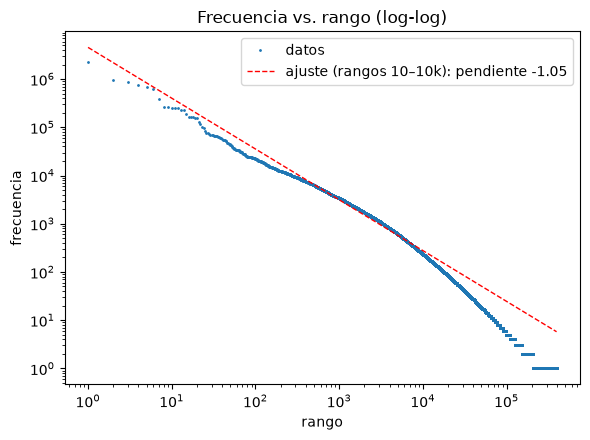

Top     10 palabras cubren  24.6% de los tokens
Top  1,000 palabras cubren  63.9% de los tokens
Top 30,000 palabras cubren  94.8% de los tokens


In [9]:
freqs = np.array(sorted(counter.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)
slope, intercept = U.zipf_fit(counter, lo=10, hi=10_000)

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.loglog(ranks, freqs, ".", ms=2, label="datos")
ax.loglog(ranks, np.exp(intercept) * ranks ** slope, "r--", lw=1,
          label=f"ajuste (rangos 10–10k): pendiente {slope:.2f}")
ax.set_xlabel("rango"); ax.set_ylabel("frecuencia"); ax.set_title("Frecuencia vs. rango (log-log)")
ax.legend(); plt.tight_layout(); plt.show()

cov = U.coverage(counter, ks=(10, 1000, 30000))
for k, v in cov.items():
    print(f"Top {k:>6,} palabras cubren {v:5.1f}% de los tokens")

## 2.5 Vocabulario y min_count

In [10]:
filas = []
for mc in [1, 5, 10, 25, 50]:
    v = U.Vocab(counter, min_count=mc)
    filas.append(dict(min_count=mc, tamano_vocab=len(v), pct_unk=round(v.unk_pct, 3)))
df_mc = pd.DataFrame(filas)
df_mc

,min_count,tamano_vocab,pct_unk
0,1,395345,0.000
1,5,109646,1.478
2,10,72573,2.287
3,25,42404,3.817
4,50,27786,5.512


In [11]:
vocab = U.Vocab(counter, min_count=MIN_COUNT)
print(f"Vocabulario elegido (min_count={MIN_COUNT}): {len(vocab):,} palabras, "
      f"{vocab.unk_pct:.2f}% de tokens desconocidos")

Vocabulario elegido (min_count=5): 109,646 palabras, 1.48% de tokens desconocidos


## 2.6 Submuestreo de palabras frecuentes (Word2Vec)

In [12]:
palabras = ["the", "of", "and"]
filas = []
for t in [1e-3, 1e-4, 1e-5]:
    for formula in ["paper", "gensim"]:
        kp = U.keep_probs(vocab, t=t, formula=formula)
        fila = dict(t=t, formula=formula)
        for w in palabras:
            fila[f"{w} (% descartado)"] = round(100 * (1 - kp[vocab.stoi[w]]), 2)
        esperados = (vocab.counts * kp).sum()
        fila["tokens conservados (%)"] = round(100 * esperados / vocab.in_vocab_total, 1)
        filas.append(fila)
pd.DataFrame(filas)

,t,formula,the (% descartado),of (% descartado),and (% descartado),tokens conservados (%)
0,0.00100,paper,88.60,82.55,81.61,73.2
1,0.00100,gensim,87.29,79.50,78.23,77.4
2,0.00010,paper,96.39,94.48,94.19,53.8
3,0.00010,gensim,96.26,94.18,93.85,60.1
4,0.00001,paper,98.86,98.25,98.16,30.2
5,0.00001,gensim,98.85,98.22,98.13,35.9


## 2.7 Codificación y pares skip-gram por epoch

In [13]:
t0 = time.time()
ids, offsets = U.encode_corpus(U.iter_paragraphs(train_rows, MAX_TOKENS), vocab, drop_unk=True)
print(f"{len(ids):,} tokens en {len(offsets)-1:,} párrafos ({time.time()-t0:.0f}s)")

# Verificación: el conteo analítico coincide con generar los pares de verdad (muestra pequeña)
mini_off = offsets[offsets <= 200_000]
mini_ids = ids[:mini_off[-1]]
gen = sum(len(c) for c, _ in U.iter_pair_chunks(mini_ids, mini_off, WINDOW, dynamic=False))
assert gen == U.count_skipgram_pairs(mini_off, WINDOW, dynamic=False)
print("Verificación OK: pares generados == pares contados")

29,552,958 tokens en 303,140 párrafos (31s)
Verificación OK: pares generados == pares contados


In [14]:
keep = U.keep_probs(vocab, t=1e-5, formula="gensim")
filas = [dict(
    submuestreo="ninguno (antes)",
    tokens=len(ids),
    pares_ventana_fija=U.count_skipgram_pairs(offsets, WINDOW),
    pares_ventana_dinamica=U.count_skipgram_pairs(offsets, WINDOW, dynamic=True),
)]
for t in [1e-3, 1e-4, 1e-5]:
    sub_ids, sub_off = U.subsample(ids, offsets, U.keep_probs(vocab, t=t), rng)
    filas.append(dict(
        submuestreo=f"t={t:g} (después)",
        tokens=len(sub_ids),
        pares_ventana_fija=U.count_skipgram_pairs(sub_off, WINDOW),
        pares_ventana_dinamica=U.count_skipgram_pairs(sub_off, WINDOW, dynamic=True),
    ))
df_pares = pd.DataFrame(filas)
df_pares["reduccion_pares_%"] = (100 * (1 - df_pares.pares_ventana_fija / df_pares.pares_ventana_fija[0])).round(1)
df_pares.style.format({"tokens": "{:,.0f}", "pares_ventana_fija": "{:,.0f}", "pares_ventana_dinamica": "{:,.0f}"})

,submuestreo,tokens,pares_ventana_fija,pares_ventana_dinamica,reduccion_pares_%
0,ninguno (antes),"29,552,958","286,516,698","173,097,993",0.000000
1,t=0.001 (después),"22,876,604","219,768,872","133,044,906",23.300000
2,t=0.0001 (después),"17,774,216","168,772,728","102,440,230",41.100000
3,t=1e-05 (después),"10,601,716","97,220,848","59,472,622",66.100000


## Guardar artefactos (para SGNS, gensim y AG News)

In [15]:
np.save(CACHE / "train_ids.npy", ids)
np.save(CACHE / "train_offsets.npy", offsets)
json.dump(dict(itos=vocab.itos, counts=vocab.counts.tolist(), min_count=MIN_COUNT,
               max_tokens=MAX_TOKENS, window=WINDOW),
          open(CACHE / "vocab.json", "w"))
print("Guardado en", CACHE.resolve())

Guardado en /Users/Camila/Desktop/CAMILA UNIVERSIDAD/8SEMESTRE/DeepLearning/Lab7-DL/cache
